In [1]:
%reload_ext autoreload
%autoreload 2


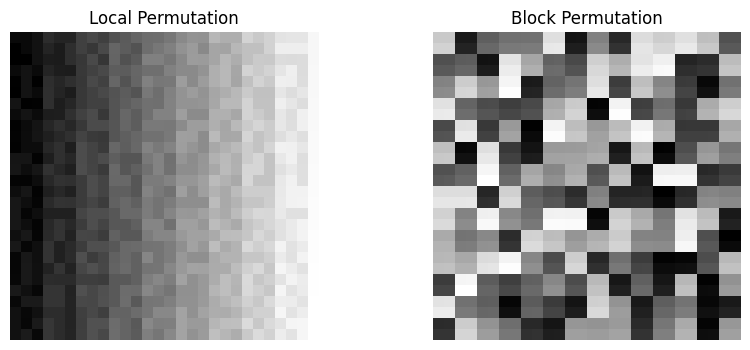

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def local_permutation_indices(height=28, width=28, window=3, orientation='horizontal', seed=None):
    """
    Generate a permutation of flattened indices such that each pixel is only permuted
    within a local window of size `window`x`window` in the 2D image.

    Args:
        height: Height of the image (default 28)
        width: Width of the image (default 28)
        window: Size of the local window (default 3)
        orientation: 'horizontal' or 'vertical' (default 'horizontal')
        seed: Optional random seed

    Returns:
        perm: A permutation of np.arange(height*width) with local shuffling
    """
    rng = np.random.default_rng(seed)
    perm = np.arange(height * width).reshape(height, width)
    out = np.empty_like(perm)
    for i in range(0, height, window):
        for j in range(0, width, window):
            h_end = min(i + window, height)
            w_end = min(j + window, width)
            block = perm[i:h_end, j:w_end].flatten()
            rng.shuffle(block)
            out[i:h_end, j:w_end] = block.reshape(h_end - i, w_end - j)

    if orientation == 'horizontal':
        out = out.T
    else:
        out = out
    return out.flatten()

def block_permutation_indices(height=28, width=28, window=3, seed=None):
    """
    Generate a permutation of flattened indices such that only the order of the blocks
    (of size window x window) is permuted, but the order within each block is preserved.

    Args:
        height: Height of the image (default 28)
        width: Width of the image (default 28)
        window: Size of the block (default 3)
        seed: Optional random seed

    Returns:
        perm: A permutation of np.arange(height*width) with block shuffling
    """
    rng = np.random.default_rng(seed)
    # Compute number of blocks in each dimension
    n_blocks_h = (height + window - 1) // window
    n_blocks_w = (width + window - 1) // window

    # List of all block start indices and their shapes
    block_indices = []
    block_shapes = []
    for i in range(n_blocks_h):
        for j in range(n_blocks_w):
            h_start = i * window
            w_start = j * window
            h_end = min(h_start + window, height)
            w_end = min(w_start + window, width)
            block = np.arange(height * width).reshape(height, width)[h_start:h_end, w_start:w_end].flatten()
            block_indices.append(block)
            block_shapes.append((h_end - h_start, w_end - w_start))

    # Permute the order of the blocks
    perm_order = np.arange(len(block_indices))
    rng.shuffle(perm_order)
    block_indices = [block_indices[i] for i in perm_order]
    block_shapes = [block_shapes[i] for i in perm_order]

    # Reconstruct the permuted array
    perm = np.empty((height, width), dtype=int)
    idx = 0
    for i in range(n_blocks_h):
        for j in range(n_blocks_w):
            h_start = i * window
            w_start = j * window
            h_end = min(h_start + window, height)
            w_end = min(w_start + window, width)
            region_shape = (h_end - h_start, w_end - w_start)
            block = block_indices[idx]
            shape = block_shapes[idx]
            # If the block size does not match the region shape, slice the block accordingly
            expected_size = region_shape[0] * region_shape[1]
            if block.size > expected_size:
                # This happens when the block was originally from a full window but the region is partial (edge)
                block = block[:expected_size]
            elif block.size < expected_size:
                # This should not happen, but just in case, raise an error
                raise ValueError(f"Cannot reshape array of size {block.size} into shape {region_shape}")
            block = block.reshape(region_shape)
            perm[h_start:h_end, w_start:w_end] = block
            idx += 1
    return perm.flatten()

# Example usage:
local_perm = local_permutation_indices(height=28, width=28, window=3, seed=44)
block_perm = block_permutation_indices(height=28, width=28, window=2, seed=44)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Local Permutation")
plt.imshow(local_perm.reshape(28,28), cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Block Permutation")
plt.imshow(block_perm.reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()

In [3]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn.nets.autoregressive import AutoregressiveTransformer, AutoregressiveMLP
from probjax.nn.nets.transformer import Transformer
from probjax.nn.attention import flex_attention
from probjax.nn import Permute, Sequential
from probjax.nn.bijective import rational_quadratic_spline
from functools import partial

from probjax.core import inverse_and_logabsdet
from probjax.stats import transformed, norm, independent


def spline_bijector(params, x):
    print(params.shape, x.shape)
    f = jax.vmap(rational_quadratic_spline)

    return f(params, x)




ar_transformer1 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=60,
    bijector=spline_bijector,
    rngs=nnx.Rngs(1),
    model_dim=128,
    num_layers = 4,
    attn_size=32,
)

mixing = Permute(block_permutation_indices(height=28, width=28, window=7, seed=44), axis=-2)
ar_transformer2 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=60,
    bijector=spline_bijector,
    rngs=nnx.Rngs(2),
    model_dim=128,
    num_layers=4,
    attn_size=32,
)
mixing2 = Permute(block_permutation_indices(height=28, width=28, window=7, seed=45), axis=-2)
ar_transformer3 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=60,
    bijector=spline_bijector,
    rngs=nnx.Rngs(3),
    model_dim=128,
    num_layers=4,
    attn_size=32,
)
mixing3 = Permute(block_permutation_indices(height=28, width=28, window=2, seed=46), axis=-2)
ar_transformer4 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=60,
    bijector=spline_bijector,
    rngs=nnx.Rngs(4),
    model_dim=128,
    num_layers=2,
    attn_size=32,
)
mixing4 = Permute(block_permutation_indices(height=28, width=28, window=2, seed=47), axis=-2)
ar_transformer5 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=60,
    bijector=spline_bijector,
    rngs=nnx.Rngs(5),
    model_dim=128,
    num_layers=2,
    attn_size=32,
)

lam = 1e-3
#flow = Sequential(ar_transformer1, mixing, ar_transformer2, mixing2, ar_transformer3, mixing3, ar_transformer4, mixing4, ar_transformer5, mixing5, ar_transformer6, mixing6, ar_transformer7, lambda x: jax.nn.sigmoid(lam + (1-2*lam)*x))
flow = Sequential(ar_transformer1, mixing, ar_transformer2, mixing2, ar_transformer3, mixing3, ar_transformer4, mixing4, ar_transformer5, lambda x: jax.nn.sigmoid(lam + (1-2*lam)*x))


In [4]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [5]:
train_data = dataset["train"]

import threading
import queue

def prefetch_generator(generator, prefetch=2):
    q = queue.Queue(prefetch)
    sentinel = object()

    def producer():
        for item in generator:
            q.put(item)
        q.put(sentinel)

    threading.Thread(target=producer, daemon=True).start()
    while True:
        item = q.get()
        if item is sentinel:
            break
        yield item

def train_data_generator(batch_size=128, prefetch=8, device=jax.devices()[0]):
    def _gen():
        while True:
            idx = np.random.randint(0, len(train_data), size=batch_size)
            xs_batch = np.array(train_data[idx]["image"], dtype=np.float32).reshape(batch_size, 28 * 28)
            # Uniform dequantization: add uniform noise in [0, 1) to each pixel, then divide by 255
            xs_batch = (xs_batch + np.random.uniform(0, 1., xs_batch.shape)) / 256

            # For numerical stability lets clip the values
            xs_batch = jnp.clip(xs_batch, 1e-6, 1-1e-6)
            # Move to device as jax array
            xs_batch = jax.device_put(xs_batch[..., None], device)

            yield xs_batch
    return prefetch_generator(_gen(), prefetch=prefetch)

datagenerator = train_data_generator()

In [6]:
xs_data = next(datagenerator)


loc0 = jnp.zeros((784,1))
scale0 = jnp.ones((784,1))
base_dist = independent(independent(norm(loc0, scale0)))

p = transformed(base_dist, flow)

graphdef, params, state = nnx.split(flow, nnx.Param,...)

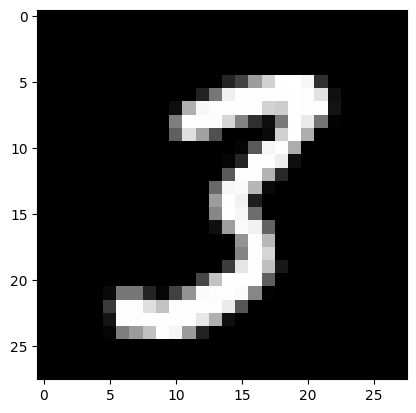

In [7]:
import matplotlib.pyplot as plt

plt.imshow(xs_data[0].reshape(28,28),cmap='gray',vmin=0,vmax=1)

In [8]:
def loss(params, xs):
    bijector = nnx.merge(graphdef, params, state)
    return jnp.mean(-transformed.logpdf(xs, base_dist, bijector))

In [9]:
@jax.jit
def update(params, opt_state, xs):
    loss_val, grads = jax.value_and_grad(loss)(params, xs)
    grads = jax.tree_util.tree_map(lambda x: jnp.nan_to_num(x, 0.), grads)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [64]:
import optax

#scheduler = optax.cosine_onecycle_schedule(50_000, 1e-4)
optimizer = optax.chain(optax.clip_by_global_norm(10.0), optax.radam(1e-4))


In [11]:
jax.clear_caches()

In [65]:
opt_state = optimizer.init(params)

In [52]:
datagenerator = train_data_generator(batch_size=128)

In [66]:
for i in range(50):
    l = 0
    for _ in range(100):
        xs_batch = next(datagenerator)
        loss_val, params, opt_state = update(params, opt_state,xs_batch)
        l += loss_val
    print(l/100)

-3834.5437
-3835.1675
-3833.9644
-3835.9534
-3834.459
-3835.0964
-3834.0593
-3831.3208
-3832.4653
-3832.9731
-3834.3208
-3833.5137
-3833.6592
-3835.5955
-3832.9546
-3833.2388
-3835.322
-3833.888
-3835.2122
-3833.9285
-3832.5981
-3833.5967
-3833.3835
-3835.0674
-3834.4834
-3831.8264
-3832.238
-3833.5571
-3829.812
-3834.9634
-3831.4468
-3835.9646
-3833.3105
-3834.86
-3832.5896
-3832.5886
-3833.4895
-3835.102
-3834.7136
-3833.481
-3836.3784
-3835.8599
-3834.4358
-3834.0684
-3834.0073
-3835.345
-3834.7727
-3833.095
-3832.8616
-3833.0505


In [67]:
# Save params
import pickle

with open('params_spline.pkl', 'wb') as f:
    pickle.dump(params, f)

# # Load params
# with open('params.pkl', 'rb') as f:
#     params = pickle.load(f)

In [68]:
bijector = nnx.merge(graphdef, params, state)
p = transformed(base_dist, bijector)


In [69]:
samples = p.rvs(jax.random.PRNGKey(0), shape=(16, ))

(784, 1)
(784, 60) (784, 1)
(784, 1)
(784, 60) (784, 1)
(784, 1)
(784, 60) (784, 1)
(784, 1)
(784, 60) (784, 1)
(784, 1)
(784, 60) (784, 1)


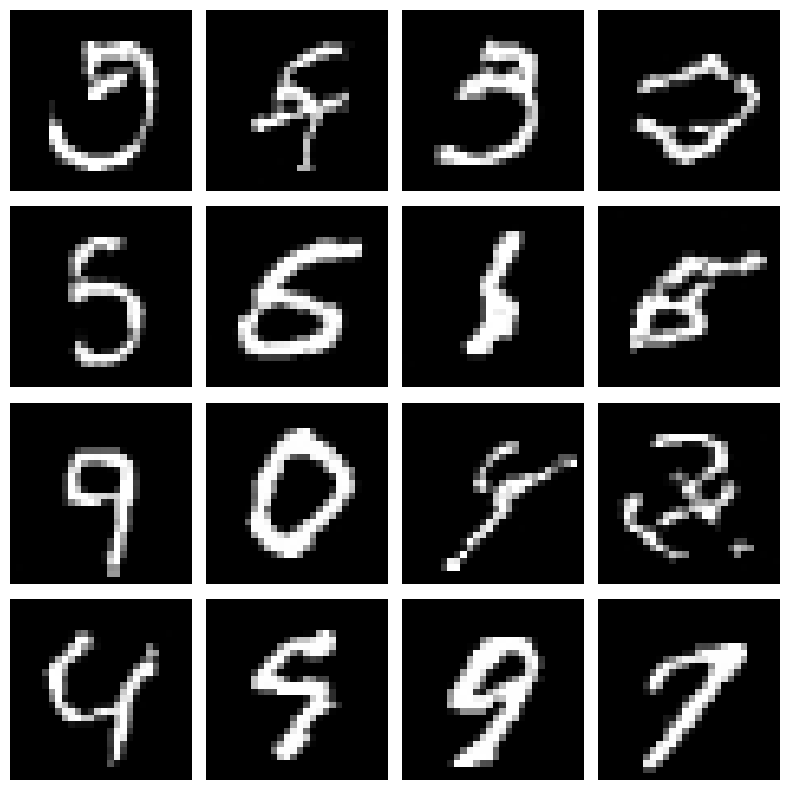

In [70]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Eval in bits per dimension

State-of-the art density estimator.

In [72]:
# Compute bits per dimension on the test set

# Get test set using datasets
test_images = dataset['test']['image']
test_images = (test_images.astype('float32') + np.random.rand(*test_images.shape)) / 256.0
test_images = test_images.clip(1e-6, 1-1e-6)
test_images = test_images.reshape(-1, 28*28)

# Compute log likelihoods in batches of 1000
batch_size = 1000
log_probs_list = []
for i in range(0, test_images.shape[0], batch_size):
    batch = test_images[i:i+batch_size]
    batch_log_probs = p.logpdf(batch)
    batch_log_probs = batch_log_probs[np.isfinite(batch_log_probs)]
    log_probs_list.append(batch_log_probs)
log_probs = np.concatenate(log_probs_list)

D = 28*28                       # 784
log_px = log_probs - D*np.log(256.0)     # subtract, not add
bits_per_dim = -log_px / (D*np.log(2.0))

print(bits_per_dim.mean())      # ≈ 1.65  (sensible for MNIST)


0.9561805023839476
